# **Домашнее задание к семинару 08-09 (HW08-HW09)**

### **Тема** 
PyTorch 101 b основы оптимизации обучения. Часть S08: MLP b регуляризация (Dropout, BatchNorm, EarlyStopping). Часть S09: learning rate диагностика, Adam vs SGD+momentum, weight decay.

### **Цель**

Закрепить:
- базовые сущности PyTorch: Tensor, Dataset/DataLoader, nn.Module, loss, optimizer, цикл обучения;
- корректный режим обучения/валидации: model.train() / model.eval() и torch.no_grad();
- практическое управление переобучением: Dropout, BatchNorm, EarlyStopping;
- базовые рычаги обучения: learning rate (плохой/хороший), сравнение Adam и SGD+momentum, использование weight decay;
- аккуратное оформление результатов: один ноутбук, короткий отчёт, артефакты эксперимента.

### **2.3.1. Импорты, seed и устройство**

Импортировать библиотеки: torch, torchvision, numpy, matplotlib (и всё, что нужно по делу).

In [43]:
import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import DataLoader, random_split

from torch.optim import Adam, SGD

Зафиксировать seed (минимум torch.manual_seed, желательно также numpy).

In [6]:
SEED = 666
torch.manual_seed(SEED)
np.random.seed(SEED)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Torch version:", torch.__version__)
print("Device:", device)

Torch version: 2.10.0+cpu
Device: cpu


### **2.3.2. Данные и DataLoader**

Загрузить выбранный датасет через torchvision.datasets.*.

Определить transform (минимум ToTensor(), нормализация – по желанию).

In [12]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

100.0%


Train size: 50000
Test size: 10000


Сделать разбиение train/val из train-части с фиксированным seed.

In [14]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

Train: 40000
Val: 10000


Создать DataLoader для train/val/test.

In [15]:
BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 313
Val batches: 79
Test batches: 79


Показать sanity-check: размеры батча, shapes (x.shape, y.shape), диапазоны значений.

In [16]:
x, y = next(iter(train_loader))

print("x shape:", x.shape)
print("y shape:", y.shape)

print("min:", x.min().item())
print("max:", x.max().item())

x shape: torch.Size([128, 3, 32, 32])
y shape: torch.Size([128])
min: 0.0
max: 1.0


Просмотр первых изображений.

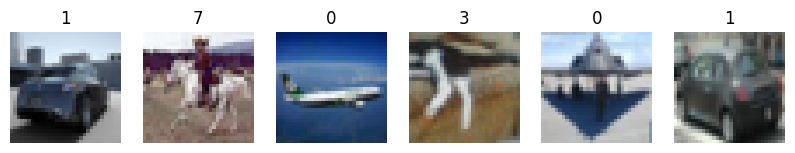

In [17]:
fig, axes = plt.subplots(1, 6, figsize=(10,3))

for i in range(6):
    axes[i].imshow(x[i].permute(1,2,0))
    axes[i].set_title(int(y[i]))
    axes[i].axis("off")

plt.show()

### **2.3.3. Модель MLP и цикл обучения**

Реализовать MLP как nn.Module (Flatten, Linear, …, logits).

In [18]:
class MLP(nn.Module):
    def __init__(self, input_size=3072, num_classes=10):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [20]:
model = MLP().to(device)

print(model)

MLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)


Выбрать:
- loss: CrossEntropyLoss;
- optimizer: Adam (по умолчанию для базовых экспериментов);
- метрика: accuracy (достаточно).

In [21]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [22]:
def accuracy(preds, targets):
    preds = torch.argmax(preds, dim=1)
    return (preds == targets).float().mean().item()

Реализовать функции (или эквивалент):
- train_one_epoch(...)
- evaluate(...) (с model.eval() и torch.no_grad())

In [23]:
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    total_loss = 0
    total_acc = 0
    n_batches = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(x)

        loss = criterion(outputs, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy(outputs, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [24]:
def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    total_acc = 0
    n_batches = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            outputs = model(x)

            loss = criterion(outputs, y)

            total_loss += loss.item()
            total_acc += accuracy(outputs, y)
            n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

Логировать историю обучения: train/val loss и train/val accuracy по эпохам.

In [25]:
EPOCHS = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
        f"train_acc={train_acc:.4f} val_acc={val_acc:.4f}"
    )

Epoch 1/10 | train_loss=1.8917 val_loss=1.7385 train_acc=0.3131 val_acc=0.3824
Epoch 2/10 | train_loss=1.6979 val_loss=1.6724 train_acc=0.3917 val_acc=0.4032
Epoch 3/10 | train_loss=1.6122 val_loss=1.6003 train_acc=0.4244 val_acc=0.4353
Epoch 4/10 | train_loss=1.5514 val_loss=1.5673 train_acc=0.4452 val_acc=0.4426
Epoch 5/10 | train_loss=1.5025 val_loss=1.5628 train_acc=0.4613 val_acc=0.4421
Epoch 6/10 | train_loss=1.4624 val_loss=1.4856 train_acc=0.4748 val_acc=0.4714
Epoch 7/10 | train_loss=1.4341 val_loss=1.5037 train_acc=0.4856 val_acc=0.4711
Epoch 8/10 | train_loss=1.4028 val_loss=1.4782 train_acc=0.4988 val_acc=0.4784
Epoch 9/10 | train_loss=1.3736 val_loss=1.4980 train_acc=0.5098 val_acc=0.4709
Epoch 10/10 | train_loss=1.3503 val_loss=1.4559 train_acc=0.5183 val_acc=0.4860


График обучения

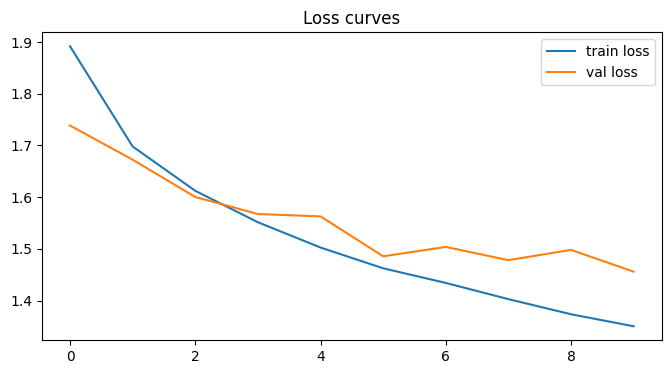

In [26]:
plt.figure(figsize=(8,4))

plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")

plt.legend()
plt.title("Loss curves")
plt.show()

### **3.1. Часть A (S08): регуляризация и переобучение (обязательно)**

Задача: показать эффект Dropout/BatchNorm и ранней остановки.

Провести 4 эксперимента (E1-E4). Эксперимент = фиксированный конфиг модели/обучения + обучение + оценка на val.
- E1 (base): MLP побольше (например, 2-3 скрытых слоя), без Dropout и без BatchNorm.
- E2 (Dropout): как E1, но добавить Dropout (например, p=0.2-0.5).
- E3 (BatchNorm): как E1, но добавить BatchNorm (между Linear и активацией).
- E4 (EarlyStopping): выбрать лучший из (E2/E3) по val_accuracy и обучить его с EarlyStopping (patience 3-5).

In [28]:
EPOCHS = 10
BATCH_SIZE = 128
LR = 1e-3

универсальная модель MLP

In [29]:
class MLP(nn.Module):

    def __init__(self, dropout=0.0, batchnorm=False):

        super().__init__()

        layers = []

        layers.append(nn.Flatten())

        layers.append(nn.Linear(3072, 512))
        if batchnorm:
            layers.append(nn.BatchNorm1d(512))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(512, 256))
        if batchnorm:
            layers.append(nn.BatchNorm1d(256))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(256, 10))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

обучение MLP

In [30]:
def train_model(model, train_loader, val_loader, epochs):

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} "
            f"| train_acc={train_acc:.4f} "
            f"| val_acc={val_acc:.4f}"
        )

    return history

E1 (base)

In [31]:
model_E1 = MLP(dropout=0.0, batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_E1.parameters(),
    lr=LR
)

history_E1 = train_model(
    model_E1,
    train_loader,
    val_loader,
    EPOCHS
)

Epoch 1/10 | train_acc=0.3157 | val_acc=0.3620
Epoch 2/10 | train_acc=0.3889 | val_acc=0.3861
Epoch 3/10 | train_acc=0.4201 | val_acc=0.4040
Epoch 4/10 | train_acc=0.4431 | val_acc=0.4415
Epoch 5/10 | train_acc=0.4598 | val_acc=0.4517
Epoch 6/10 | train_acc=0.4780 | val_acc=0.4617
Epoch 7/10 | train_acc=0.4828 | val_acc=0.4625
Epoch 8/10 | train_acc=0.4962 | val_acc=0.4655
Epoch 9/10 | train_acc=0.5082 | val_acc=0.4684
Epoch 10/10 | train_acc=0.5164 | val_acc=0.4804


E2 (Dropout)

In [32]:
model_E2 = MLP(dropout=0.3, batchnorm=False).to(device)

optimizer = torch.optim.Adam(
    model_E2.parameters(),
    lr=LR
)

history_E2 = train_model(
    model_E2,
    train_loader,
    val_loader,
    EPOCHS
)

Epoch 1/10 | train_acc=0.2771 | val_acc=0.3420
Epoch 2/10 | train_acc=0.3383 | val_acc=0.3652
Epoch 3/10 | train_acc=0.3574 | val_acc=0.3884
Epoch 4/10 | train_acc=0.3675 | val_acc=0.3925
Epoch 5/10 | train_acc=0.3721 | val_acc=0.4094
Epoch 6/10 | train_acc=0.3806 | val_acc=0.4158
Epoch 7/10 | train_acc=0.3875 | val_acc=0.4163
Epoch 8/10 | train_acc=0.3936 | val_acc=0.4363
Epoch 9/10 | train_acc=0.4002 | val_acc=0.4324
Epoch 10/10 | train_acc=0.4024 | val_acc=0.4408


E3 (BatchNorm)

In [33]:
model_E3 = MLP(dropout=0.0, batchnorm=True).to(device)

optimizer = torch.optim.Adam(
    model_E3.parameters(),
    lr=LR
)

history_E3 = train_model(
    model_E3,
    train_loader,
    val_loader,
    EPOCHS
)

Epoch 1/10 | train_acc=0.4225 | val_acc=0.4259
Epoch 2/10 | train_acc=0.5040 | val_acc=0.4468
Epoch 3/10 | train_acc=0.5475 | val_acc=0.5110
Epoch 4/10 | train_acc=0.5784 | val_acc=0.4750
Epoch 5/10 | train_acc=0.6068 | val_acc=0.4379
Epoch 6/10 | train_acc=0.6344 | val_acc=0.4487
Epoch 7/10 | train_acc=0.6591 | val_acc=0.4822
Epoch 8/10 | train_acc=0.6864 | val_acc=0.5139
Epoch 9/10 | train_acc=0.7119 | val_acc=0.4621
Epoch 10/10 | train_acc=0.7380 | val_acc=0.5207


E4 (EarlyStopping)

In [50]:
history_E4 = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

model_E4 = MLP(dropout=0.0, batchnorm=True).to(device)

optimizer = torch.optim.Adam(
    model_E4.parameters(),
    lr=LR
)

patience = 4
best_val = 0
counter = 0

for epoch in range(50):

    train_loss, train_acc = train_one_epoch(
        model_E4, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc = evaluate(
        model_E4, val_loader, criterion, device
    )

    history_E4["train_loss"].append(train_loss)
    history_E4["val_loss"].append(val_loss)
    history_E4["train_acc"].append(train_acc)
    history_E4["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1} val_acc={val_acc:.4f}")

    if val_acc > best_val:
        best_val = val_acc
        counter = 0

        torch.save(
            model_E4.state_dict(),
            "artifacts/best_model.pt"
        )
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

Epoch 1 val_acc=0.4174
Epoch 2 val_acc=0.4647
Epoch 3 val_acc=0.4718
Epoch 4 val_acc=0.4805
Epoch 5 val_acc=0.4950
Epoch 6 val_acc=0.4844
Epoch 7 val_acc=0.5099
Epoch 8 val_acc=0.4908
Epoch 9 val_acc=0.4961
Epoch 10 val_acc=0.4800
Epoch 11 val_acc=0.4536
Early stopping


Проверка модели E4 на test.

In [48]:
model = MLP(dropout=0.0, batchnorm=True).to(device)

model.load_state_dict(
    torch.load("artifacts/model_E4.pt")
)

test_loss, test_acc = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("Final test accuracy:", test_acc)

Final test accuracy: 0.520371835443038


### **3.2. Часть B (S09): LR, оптимизаторы, weight decay (обязательно)**

Задача: научиться диагностировать плохой LR по кривым, а также руками настроить SGD+momentum и weight decay.

Делаем 3 коротких эксперимента (O1-O3) на фиксированной архитектуре (той же, что в E4 по слоям/нейронам/Dropout/BN).

- O1 (LR слишком большой): Adam, lr = "слишком большой" (например, 1e-1). Обучить 5-8 эпох и показать, что loss/метрики ведут себя плохо.
- O2 (LR слишком маленький): Adam, lr = "слишком маленький" (например, 1e-5). Обучить 5-8 эпох и показать, что обучение почти не двигается.
- O3 (SGD+momentum + weight decay): SGD с momentum (например, momentum=0.9) и weight_decay > 0 (например, 1e-4).
  - lr взять разумный (например, как в E4 или подобрать в диапазоне 1e-2…1e-3).
  - обучить 10-15 эпох (или меньше, если на CPU долго).

O1 (LR слишком большой)

In [38]:
optimizer = Adam
lr = 1e-1
epochs = 6

In [39]:
model_O1 = MLP(dropout=0.0, batchnorm=True).to(device)

optimizer = torch.optim.Adam(
    model_O1.parameters(),
    lr=1e-1
)

history_O1 = train_model(
    model_O1,
    train_loader,
    val_loader,
    epochs=6
)

Epoch 1/6 | train_acc=0.3291 | val_acc=0.3435
Epoch 2/6 | train_acc=0.4145 | val_acc=0.2983
Epoch 3/6 | train_acc=0.4534 | val_acc=0.4307
Epoch 4/6 | train_acc=0.4726 | val_acc=0.4174
Epoch 5/6 | train_acc=0.4938 | val_acc=0.4665
Epoch 6/6 | train_acc=0.5056 | val_acc=0.4241


O2 (LR слишком маленький)

In [40]:
optimizer = Adam
lr = 1e-5
epochs = 6

In [41]:
model_O2 = MLP(dropout=0.0, batchnorm=True).to(device)

optimizer = torch.optim.Adam(
    model_O2.parameters(),
    lr=1e-5
)

history_O2 = train_model(
    model_O2,
    train_loader,
    val_loader,
    epochs=6
)

Epoch 1/6 | train_acc=0.3276 | val_acc=0.3833
Epoch 2/6 | train_acc=0.4218 | val_acc=0.4232
Epoch 3/6 | train_acc=0.4552 | val_acc=0.4449
Epoch 4/6 | train_acc=0.4779 | val_acc=0.4634
Epoch 5/6 | train_acc=0.4956 | val_acc=0.4701
Epoch 6/6 | train_acc=0.5092 | val_acc=0.4823


O3 (SGD+momentum + weight decay)

In [44]:
optimizer = SGD
momentum = 0.9
weight_decay = 1e-4
lr = 1e-2
epochs = 12

In [45]:
model_O3 = MLP(dropout=0.0, batchnorm=True).to(device)

optimizer = torch.optim.SGD(
    model_O3.parameters(),
    lr=1e-2,
    momentum=0.9,
    weight_decay=1e-4
)

history_O3 = train_model(
    model_O3,
    train_loader,
    val_loader,
    epochs=12
)

Epoch 1/12 | train_acc=0.4257 | val_acc=0.4382
Epoch 2/12 | train_acc=0.5071 | val_acc=0.4583
Epoch 3/12 | train_acc=0.5471 | val_acc=0.3977
Epoch 4/12 | train_acc=0.5814 | val_acc=0.4643
Epoch 5/12 | train_acc=0.6121 | val_acc=0.4246
Epoch 6/12 | train_acc=0.6387 | val_acc=0.4542
Epoch 7/12 | train_acc=0.6646 | val_acc=0.4673
Epoch 8/12 | train_acc=0.6847 | val_acc=0.4376
Epoch 9/12 | train_acc=0.7028 | val_acc=0.4703
Epoch 10/12 | train_acc=0.7283 | val_acc=0.4490
Epoch 11/12 | train_acc=0.7510 | val_acc=0.4624
Epoch 12/12 | train_acc=0.7695 | val_acc=0.4400


### **4. Артефакты (обязательно)**

figures/curves_best.png – график train/val loss (или loss+accuracy) для лучшего прогона (E4).

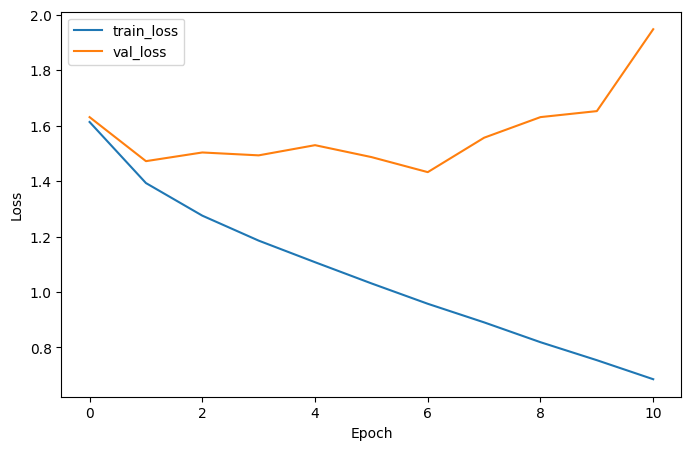

In [51]:
plt.figure(figsize=(8,5))

plt.plot(history_E4["train_loss"], label="train_loss")
plt.plot(history_E4["val_loss"], label="val_loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("artifacts/figures/curves_best.png")
plt.show()

figures/curves_lr_extremes.png – график(и), показывающий(ие) поведение O1 и O2 (LR слишком большой/маленький).

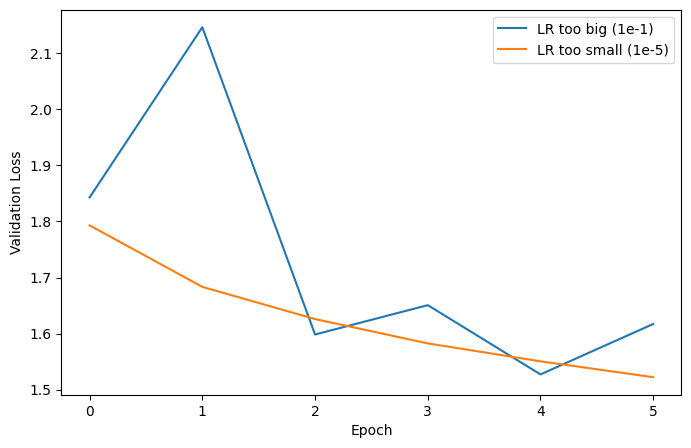

In [47]:
plt.figure(figsize=(8,5))

plt.plot(history_O1["val_loss"], label="LR too big (1e-1)")
plt.plot(history_O2["val_loss"], label="LR too small (1e-5)")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()

plt.savefig("artifacts/figures/curves_lr_extremes.png")
plt.show()

Заполнение run.csv

In [53]:
def get_best_val_loss(history):
    if "val_loss" in history and len(history["val_loss"]) > 0:
        return min(history["val_loss"])
    else:
        return None

In [54]:
best_val_loss_E1 = get_best_val_loss(history_E1)
best_val_loss_E2 = get_best_val_loss(history_E2)
best_val_loss_E3 = get_best_val_loss(history_E3)
best_val_loss_E4 = get_best_val_loss(history_E4)

best_val_loss_O1 = get_best_val_loss(history_O1)
best_val_loss_O2 = get_best_val_loss(history_O2)
best_val_loss_O3 = get_best_val_loss(history_O3)

print("E1 best_val_loss:", best_val_loss_E1)
print("E2 best_val_loss:", best_val_loss_E2)
print("E3 best_val_loss:", best_val_loss_E3)
print("E4 best_val_loss:", best_val_loss_E4)

print("O1 best_val_loss:", best_val_loss_O1)
print("O2 best_val_loss:", best_val_loss_O2)
print("O3 best_val_loss:", best_val_loss_O3)

E1 best_val_loss: 1.4686636970013003
E2 best_val_loss: 1.6047993204261684
E3 best_val_loss: 1.4003987568843215
E4 best_val_loss: 1.432551794414279
O1 best_val_loss: 1.5272011907794807
O2 best_val_loss: 1.522190848483315
O3 best_val_loss: 1.5192188084880007
